In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/drug-discovery/my_dataframe (1).csv


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

2025-05-10 04:22:37.449700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746850957.805286      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746850957.886713      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
df = pd.read_csv('/kaggle/input/drug-discovery/my_dataframe (1).csv')
df.head()

,SMILES,MolecularWeight,XLogP,ExactMass,MonoisotopicMass,TPSA,Complexity,HBondDonorCount,HBondAcceptorCount,RotatableBondCount,...,FeatureAcceptorCount3D,FeatureDonorCount3D,FeatureAnionCount3D,FeatureCationCount3D,FeatureRingCount3D,FeatureHydrophobeCount3D,ConformerModelRMSD3D,EffectiveRotorCount3D,ConformerCount3D,pIC50
0,ClC1=CC(NC(=O)CSC2=NC=CC(=N2)C2=CSC(=N2)C2=CC=...,473.4,5.6,471.998609,471.998609,121.0,559.0,1.0,6.0,6.0,...,3.0,1.0,0.0,1.0,4.0,0.0,1.0,7.0,10.0,-0.477121
1,CN1N=C(C=C1C(F)(F)F)C1=CC=C(S1)C1=CC=NC(SCC(=O...,510.0,4.9,509.035865,509.035865,126.0,670.0,1.0,9.0,6.0,...,3.0,1.0,0.0,1.0,4.0,0.0,1.2,8.0,10.0,-1.000000
2,CSC1=C(C(C)=C(S1)C1=NC(C)=CS1)C1=CC=NC(SCC(=O)...,519.1,6.3,518.013024,518.013024,175.0,627.0,1.0,8.0,7.0,...,3.0,1.0,0.0,1.0,4.0,1.0,1.0,8.0,10.0,-1.041393
3,CC1=NC(=CS1)C1=NC(=CS1)C1=NC(SCC(=O)NC2=CC=C(C...,460.0,4.4,459.004901,459.004901,162.0,554.0,1.0,8.0,6.0,...,4.0,1.0,0.0,1.0,4.0,0.0,1.0,7.0,10.0,-1.146128
4,ClC1=CC=C(NC(=O)CSC2=NC=CC(=N2)C2=CC(=NO2)C2=C...,422.9,4.4,422.060425,422.060425,106.0,529.0,1.0,6.0,6.0,...,3.0,1.0,0.0,1.0,4.0,0.0,1.0,7.0,10.0,-1.176091


In [8]:
df_clean = df.drop(columns=['SMILES'])
df_clean.head()

,MolecularWeight,XLogP,ExactMass,MonoisotopicMass,TPSA,Complexity,HBondDonorCount,HBondAcceptorCount,RotatableBondCount,HeavyAtomCount,...,FeatureAcceptorCount3D,FeatureDonorCount3D,FeatureAnionCount3D,FeatureCationCount3D,FeatureRingCount3D,FeatureHydrophobeCount3D,ConformerModelRMSD3D,EffectiveRotorCount3D,ConformerCount3D,pIC50
0,473.4,5.6,471.998609,471.998609,121.0,559.0,1.0,6.0,6.0,30.0,...,3.0,1.0,0.0,1.0,4.0,0.0,1.0,7.0,10.0,-0.477121
1,510.0,4.9,509.035865,509.035865,126.0,670.0,1.0,9.0,6.0,33.0,...,3.0,1.0,0.0,1.0,4.0,0.0,1.2,8.0,10.0,-1.000000
2,519.1,6.3,518.013024,518.013024,175.0,627.0,1.0,8.0,7.0,32.0,...,3.0,1.0,0.0,1.0,4.0,1.0,1.0,8.0,10.0,-1.041393
3,460.0,4.4,459.004901,459.004901,162.0,554.0,1.0,8.0,6.0,29.0,...,4.0,1.0,0.0,1.0,4.0,0.0,1.0,7.0,10.0,-1.146128
4,422.9,4.4,422.060425,422.060425,106.0,529.0,1.0,6.0,6.0,29.0,...,3.0,1.0,0.0,1.0,4.0,0.0,1.0,7.0,10.0,-1.176091


In [10]:
scaler = StandardScaler()
X = df_clean.drop(columns=['pIC50'])
y = df_clean['pIC50']

In [13]:
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.29847019,  1.55117009,  1.28906101, ...,  0.94710774,
         0.9183081 ,  0.42079838],
       [ 1.78840455,  1.10121775,  1.78569935, ...,  1.87384757,
         1.3651853 ,  0.42079838],
       [ 1.91021883,  2.00112244,  1.90607548, ...,  0.94710774,
         1.3651853 ,  0.42079838],
       ...,
       [ 0.92231841,  0.97265994,  0.92654101, ..., -0.90637192,
        -0.77982527,  0.42079838],
       [ 1.95840909,  0.90838103,  1.95860137, ...,  0.02036791,
         0.11392913,  0.42079838],
       [ 1.39083487,  0.13703415,  1.39635908, ...,  0.02036791,
         0.20330457,  0.42079838]])

In [15]:
X_tensor = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
y_tensor = tf.convert_to_tensor(y.values, dtype=tf.float32)
X_tensor

<tf.Tensor: shape=(91, 28), dtype=float32, numpy=
array([[ 1.2984701 ,  1.5511701 ,  1.2890611 , ...,  0.94710773,
         0.9183081 ,  0.4207984 ],
       [ 1.7884046 ,  1.1012177 ,  1.7856994 , ...,  1.8738476 ,
         1.3651853 ,  0.4207984 ],
       [ 1.9102188 ,  2.0011225 ,  1.9060755 , ...,  0.94710773,
         1.3651853 ,  0.4207984 ],
       ...,
       [ 0.9223184 ,  0.97265995,  0.92654103, ..., -0.90637195,
        -0.77982527,  0.4207984 ],
       [ 1.9584091 ,  0.90838104,  1.9586014 , ...,  0.02036791,
         0.11392913,  0.4207984 ],
       [ 1.3908348 ,  0.13703415,  1.3963591 , ...,  0.02036791,
         0.20330457,  0.4207984 ]], dtype=float32)>

In [16]:
y_tensor

<tf.Tensor: shape=(91,), dtype=float32, numpy=
array([-0.47712126, -1.        , -1.0413927 , -1.146128  , -1.1760913 ,
       -1.1760913 , -1.1760913 , -1.4771212 , -1.60206   , -1.60206   ,
       -1.6532125 , -1.7781513 , -1.7781513 , -2.        , -2.30103   ,
       -2.30103   , -2.30103   , -2.30103   , -2.30103   , -2.39794   ,
       -2.4771214 , -2.4771214 , -2.544068  , -2.60206   , -2.69897   ,
       -1.3944517 , -1.3242824 , -2.3554516 , -1.587711  , -1.1583625 ,
       -1.3242824 ,  0.52287877,  0.04575749, -0.7781513 , -1.0791812 ,
       -1.1139433 , -1.1139433 , -1.1760913 , -1.20412   , -1.20412   ,
       -1.39794   , -0.47712126, -0.69897   , -1.        , -1.1760913 ,
       -1.20412   , -1.2552725 , -1.2552725 , -1.30103   , -1.60206   ,
        1.2006594 ,  1.2218487 ,  0.6819367 ,  0.30103   ,  0.78515613,
        0.15676722,  0.47755575,  0.1649439 ,  0.9065783 ,  0.9665762 ,
       -1.5011963 , -1.5062344 , -1.5429498 , -1.0030295 , -1.7103713 ,
       -1.1024337

In [21]:
X_numpy = X_scaled
y_numpy = y.values
y_numpy

array([-0.47712126, -1.        , -1.04139268, -1.14612804, -1.17609126,
       -1.17609126, -1.17609126, -1.47712125, -1.60205999, -1.60205999,
       -1.65321251, -1.77815125, -1.77815125, -2.        , -2.30103   ,
       -2.30103   , -2.30103   , -2.30103   , -2.30103   , -2.39794001,
       -2.47712126, -2.47712126, -2.54406804, -2.60205999, -2.69897   ,
       -1.39445168, -1.32428246, -2.35545152, -1.58771097, -1.15836249,
       -1.32428246,  0.52287874,  0.04575749, -0.77815125, -1.07918125,
       -1.11394335, -1.11394335, -1.17609126, -1.20411998, -1.20411998,
       -1.39794001, -0.47712126, -0.69897   , -1.        , -1.17609126,
       -1.20411998, -1.2552725 , -1.2552725 , -1.30103   , -1.60205999,
        1.20065945,  1.22184875,  0.68193667,  0.30103   ,  0.78515615,
        0.15676722,  0.47755577,  0.1649439 ,  0.90657831,  0.96657624,
       -1.50119624, -1.50623436, -1.54294985, -1.00302947, -1.71037126,
       -1.10243371, -0.07188201, -0.35218252, -0.63346846, -1.07

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_numpy, y_numpy, test_size=0.2, random_state=42)
X_train, X_test

(array([[-0.05353444, -1.59849632, -0.05063949, ...,  0.02036791,
         -0.24357263,  0.42079838],
        [ 1.80312935,  1.74400681,  1.79990275, ...,  2.8005874 ,
          2.2589397 ,  0.42079838],
        [-0.91091956, -1.3413807 , -0.90890791, ..., -0.90637192,
         -0.69044983,  0.42079838],
        ...,
        [-0.88441491, -2.43412211, -0.88236763, ..., -0.90637192,
         -0.69044983,  0.42079838],
        [ 0.341358  ,  0.32987087,  0.33783535, ...,  1.87384757,
          0.9183081 ,  0.42079838],
        [-0.42433175,  0.39414978, -0.42702413, ...,  0.02036791,
          0.02455369,  0.42079838]]),
 array([[-9.11990453e-01, -4.41476006e-01, -9.09883703e-01,
         -9.10178967e-01,  1.06839956e+00, -8.40249298e-01,
         -8.53668841e-01,  2.08540979e-01, -9.49163080e-01,
         -8.70908172e-01, -3.31294578e-01, -3.31294578e-01,
         -1.05409255e-01, -1.05409255e-01, -1.04437311e+00,
         -1.14948461e-01, -9.11292419e-01, -1.17320003e-01,
          9.6

In [27]:
import tensorflow as tf
from tensorflow.keras.callbacks import Callback

In [29]:
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print("Using GPU")
else:
    print("GPU not found. Using CPU instead.")


Using GPU


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import r2_score, mean_squared_error

In [54]:
class MetricsLogger(Callback):
    def __init__(self):
        super(MetricsLogger, self).__init__()
        self.history = {
            'loss': [],
            'val_loss': [],
            'mae': [],
            'val_mae': [],
            'r2': [],
            'val_r2': [],
            'rmse': [],
            'val_rmse': []
        }

In [55]:
def on_epoch_end(self, epoch, logs=None):
        # Calculate R² and RMSE for training and validation data
        y_train_pred = self.model.predict(self.model.validation_data[0], batch_size=32)
        y_test_pred = self.model.predict(self.model.validation_data[0], batch_size=32)
        
        r2_train = r2_score(self.model.validation_data[1], y_train_pred)
        r2_val = r2_score(self.model.validation_data[1], y_test_pred)
        
        rmse_train = np.sqrt(mean_squared_error(self.model.validation_data[1], y_train_pred))
        rmse_val = np.sqrt(mean_squared_error(self.model.validation_data[1], y_test_pred))
        
        # Store the metrics at the end of each epoch
        self.history['loss'].append(logs['loss'])
        self.history['val_loss'].append(logs['val_loss'])
        self.history['mae'].append(logs['mae'])
        self.history['val_mae'].append(logs['val_mae'])
        self.history['r2'].append(r2_train)
        self.history['val_r2'].append(r2_val)
        self.history['rmse'].append(rmse_train)
        self.history['val_rmse'].append(rmse_val)

In [91]:
class TransformerModel(tf.keras.Model):
    def __init__(self, num_features, embed_size=64, num_heads=4, num_layers=2):
        super(TransformerModel, self).__init__()
        self.embedding = layers.Dense(embed_size)
        self.positional_encoding = layers.Embedding(input_dim=num_features, output_dim=embed_size)
        
        self.transformer_blocks = [
            layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_size)
            for _ in range(num_layers)
        ]
        
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(128, activation='relu')
        self.dense2 = layers.Dense(1, activation='linear')  # Regression output
    
    def call(self, inputs):
        # Reshape the input to (batch_size, seq_len, feature_size)
        x = tf.expand_dims(inputs, axis=1)  # Adding a sequence dimension
        
        x = self.embedding(x)
        x = x + self.positional_encoding(tf.range(0, tf.shape(x)[1]))  # Add positional encoding
        
        for transformer in self.transformer_blocks:
            x = transformer(x, x)
        
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.dense2(x)
        
        return x

# Initialize the transformer model
num_features = X_train.shape[1]
model = TransformerModel(num_features)
model

<TransformerModel name=transformer_model_18, built=False>

In [92]:
# Compile the model
model.compile(optimizer='adamW', loss='mse', metrics=['mae'])

# Create the callback instance
metrics_logger = MetricsLogger()

# Train the model with the metrics logger
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=[metrics_logger])

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 828ms/step - loss: 1.7339 - mae: 1.1470 - val_loss: 1.3917 - val_mae: 1.0558
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1663 - mae: 0.9224 - val_loss: 0.6950 - val_mae: 0.7026
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7615 - mae: 0.7525 - val_loss: 0.6127 - val_mae: 0.6634
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6774 - mae: 0.6982 - val_loss: 0.7337 - val_mae: 0.7322
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6212 - mae: 0.6672 - val_loss: 0.6444 - val_mae: 0.6715
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4848 - mae: 0.5763 - val_loss: 0.6048 - val_mae: 0.6882
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4501 - mae: 0.5516 - val_loss: 0.4147 - val_mae: 0.5297
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3611 - mae: 0.4797 - val_loss: 0.3573 - val_mae: 0.4903
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3847 - mae: 0.4901 -

In [90]:
loss, mae = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss}")
print(f"Test MAE: {mae}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5911 - mae: 0.6362
Test Loss: 0.5911026000976562
Test MAE: 0.6362197995185852


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (19, 16, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step


<Axes: >

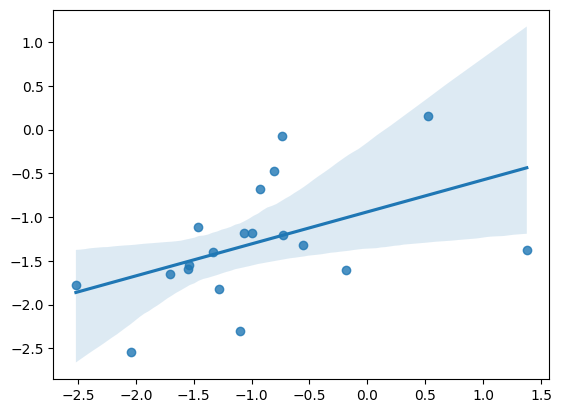

In [72]:
pred = model.predict(X_test)

sns.regplot(x = pred, y = y_test)